# Proyecto Tutorial de Clasficador de Imagenes

In [ ]:
import os
import random
import shutil
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import zipfile

import keras
from keras.preprocessing import image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Sequential

from keras.preprocessing import image
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from keras.optimizers import Adam



In [ ]:
# Carpeta donde están TODAS las imágenes mezcladas
data_dir = "../data/dogs-vs-cats"

# Crear estructura de carpetas final
train_cats = os.path.join(data_dir, "train", "cats")
train_dogs = os.path.join(data_dir, "train", "dogs")
test_cats  = os.path.join(data_dir, "test", "cats")
test_dogs  = os.path.join(data_dir, "test", "dogs")

for folder in [train_cats, train_dogs, test_cats, test_dogs]:
    os.makedirs(folder, exist_ok=True)

# Listar imágenes
all_images = [img for img in os.listdir(data_dir) if img.endswith(".jpg")]

# Separar por clase según el nombre del archivo
cat_images = [img for img in all_images if img.lower().startswith("cat")]
dog_images = [img for img in all_images if img.lower().startswith("dog")]

def split_and_copy(images, train_path, test_path, train_ratio=0.8):
    random.shuffle(images)
    split_idx = int(len(images) * train_ratio)

    train_imgs = images[:split_idx]
    test_imgs  = images[split_idx:]

    # Copiar a destino
    for img in train_imgs:
        shutil.copy(os.path.join(data_dir, img), train_path)

    for img in test_imgs:
        shutil.copy(os.path.join(data_dir, img), test_path)

    print(f"{train_path}: {len(train_imgs)} imágenes")
    print(f"{test_path}: {len(test_imgs)} imágenes\n")

# Aplicar split para cada clase
split_and_copy(cat_images, train_cats, test_cats)
split_and_copy(dog_images, train_dogs, test_dogs)

../data/dogs-vs-cats/train/cats: 10000 imágenes
../data/dogs-vs-cats/test/cats: 2500 imágenes

../data/dogs-vs-cats/train/dogs: 10000 imágenes
../data/dogs-vs-cats/test/dogs: 2500 imágenes



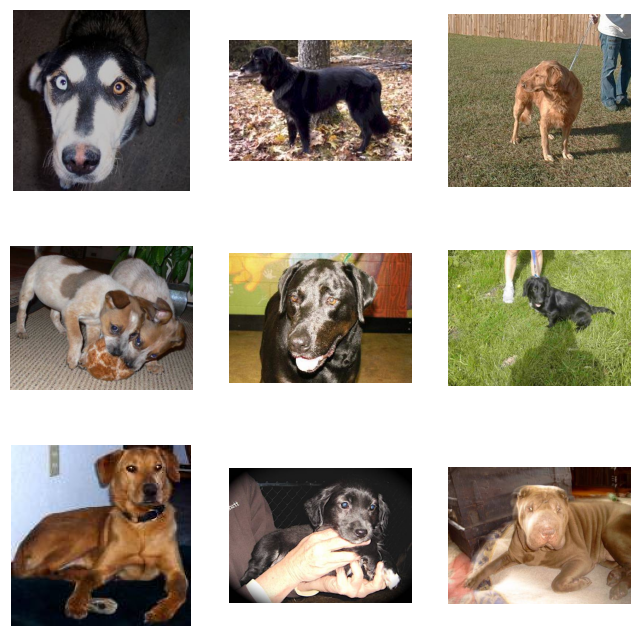

In [ ]:
#path to train data

train_path = '../data/dogs-vs-cats/train'
dogs_dir = os.path.join(train_path, 'dogs')
cats_dir = os.path.join(train_path, 'cats')

# function to display first 9 images
def show_first_9_images(img_folder, title):
    plt.figure(figsize=(8,8))
    images = os.listdir(img_folder)[:9]
    for i, img_name in enumerate(images):
        img_path = os.path.join(img_folder, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()
show_first_9_images(dogs_dir, 'Dogs')

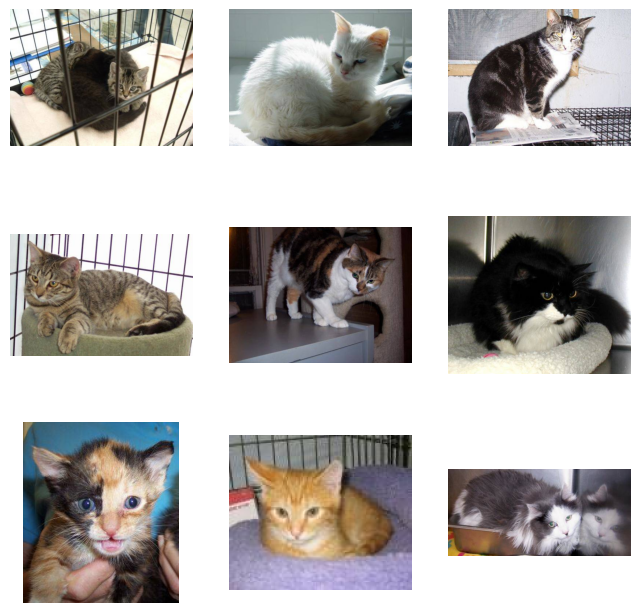

In [ ]:
# function to display first 9 images
def show_first_9_images(img_folder, title):
    plt.figure(figsize=(8,8))
    images = os.listdir(img_folder)[:9]
    for i, img_name in enumerate(images):
        img_path = os.path.join(img_folder, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()
show_first_9_images(cats_dir, 'Cats')

In [ ]:
train_dir = "../data/dogs-vs-cats/train"
image_size = (200, 200)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(train_dir,
                                         target_size=image_size,
                                         batch_size=32,
                                         class_mode="binary",
                                         subset="training",
                                         shuffle=True)

test_data = datagen.flow_from_directory(train_dir,
                                        target_size=image_size,
                                        batch_size=32,
                                        class_mode="binary",
                                        subset="validation",
                                        shuffle=False)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
model = Sequential()

# 1. Bloque de Extracción de Característica Principal (Principio)
# Simulación del Bloque 1
model.add(Conv2D(input_shape = (200,200,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (112, 112, 64)

# 2. Bloque de Característica 1
# Simulación del Bloque 2
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (56, 56, 128)

# 3. Bloque de Característica 2
# Simulación del Bloque 3
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
# Eliminamos una capa Conv2D para simplificar el bloque
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (28, 28, 256)

# 4. Bloque de Característica 3
# Simulación de parte de los Bloques 4 y 5, usando menos filtros densos
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
# Eliminamos la capa Conv2D adicional para simplificar
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (14, 14, 512)

# 5. Capas de Clasificación (Fin)
model.add(Flatten()) # Aplanar los datos: 14 * 14 * 512 = 100352 unidades
# Reducimos las capas densas de 4096 a un valor más pequeño, por ejemplo, 512 o 1024
model.add(Dense(units = 1024, activation = "relu"))
# Eliminamos una capa densa para simplificar
model.add(Dense(units = 2, activation = "softmax")) # Capa de salida para 2 clases

In [ ]:
# Compile the Model before Training
model.compile(loss=keras.losses.categorical_crossentropy, 
              optimizer = Adam(learning_rate = 0.001), 
              metrics = ["accuracy"])

NameError: name 'model' is not defined

In [ ]:
history = model.fit(
    train_data,
    epochs=1,
    validation_data=test_data
)


NameError: name 'model' is not defined